# Biomedical Literature Search with Hugging Face + SQL

**Portfolio project:** lexical and semantic literature retrieval, zero-shot classification, SQL data workflows, and quantitative model evaluation.

This notebook develops the project in four parts:

1. **Deterministic prototype** — a small synthetic biomedical corpus validates the SQL, embedding, retrieval, classification, and error-analysis pipeline.
2. **Curated PubMed retrieval benchmark** — the retrieval workflow is tested on 80 manually curated PubMed papers and compared against a conventional SQLite FTS5/BM25 lexical-search baseline.
3. **Retrieval disagreement analysis** — the lexical and semantic rankings are inspected directly to understand where the methods differ.
4. **Real-data zero-shot classification** — the zero-shot classifier is evaluated on the same curated PubMed corpus.

The central question is not whether a pretrained transformer can be invoked successfully, but whether it adds useful behavior inside a reproducible and inspectable data-science workflow.

### What this demonstrates

- Python data pipelines with pandas / NumPy
- SQL and SQLite
- full-text search with SQLite FTS5 / BM25
- Hugging Face Sentence Transformers and dense embeddings
- semantic retrieval with cosine similarity
- quantitative retrieval evaluation with Precision@K and MRR
- Hugging Face zero-shot classification
- accuracy, macro-F1, confusion matrices, confidence analysis, and failure review
- iterative movement from a controlled prototype to a curated real-data benchmark


## 1. Environment and setup

Recommended Python: **3.12** for the tested environment.

Install the project dependencies with:

```bash
pip install -r requirements.txt
```

The first model run downloads pretrained weights from Hugging Face.

The curated PubMed corpus used in Part II is generated locally from the committed PMID/label manifest:

```bash
export NCBI_EMAIL="your-email@example.com"
python scripts/fetch_curated_pubmed.py
```

The resulting abstract cache is intentionally excluded from Git; `data/pubmed_labels.csv` contains the committed human-curated labels.


In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from transformers import pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CACHE_DIR = Path("data/cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

SYNTHETIC_DB_PATH = CACHE_DIR / "synthetic_literature.db"
REAL_DB_PATH = CACHE_DIR / "pubmed_literature.db"

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
ZERO_SHOT_MODEL = "MoritzLaurer/DeBERTa-v3-base-mnli"


# Part I — Deterministic prototype

The first stage uses short **synthetic summaries** rather than copied abstracts. This makes the initial pipeline fast, deterministic, and easy to inspect while the basic SQL and Hugging Face workflow is being validated.

The prototype uses four broad biomedical domains:

- `myelin_connectomics`
- `eeg_memory`
- `neurodevelopment`
- `pediatric_complex_care`

These synthetic topic labels are exact by construction, so Part I should be treated as a **pipeline smoke test**, not as a realistic retrieval benchmark.


In [2]:
TOPICS = {
    "myelin_connectomics": {
        "semantic_query": "How does white matter myelin influence communication and connectivity between brain regions?",
        "display_label": "myelin and brain connectivity",
    },
    "eeg_memory": {
        "semantic_query": "EEG signals and electrophysiological mechanisms related to human memory",
        "display_label": "EEG and memory",
    },
    "neurodevelopment": {
        "semantic_query": "brain development, neurodevelopment, and developmental neuroimaging",
        "display_label": "neurodevelopment",
    },
    "pediatric_complex_care": {
        "semantic_query": "care coordination and outcomes for children with complex medical needs",
        "display_label": "pediatric complex care",
    },
}

LABEL_TO_TOPIC = {v["display_label"]: k for k, v in TOPICS.items()}

SYNTHETIC_PAPERS = [
    ("M001", "Myelin-sensitive MRI and network communication",
     "We examine whether regional variation in white-matter myelin is associated with communication efficiency across structural brain networks. Myelin-sensitive measurements are integrated with tractography-derived connectivity and graph communication models.",
     2025, "myelin_connectomics"),
    ("M002", "White-matter microstructure and functional coupling",
     "This study evaluates relationships between tract microstructure, conduction-related features, and functional connectivity. Network models are compared across spatial scales to identify robust structure-function associations.",
     2024, "myelin_connectomics"),
    ("M003", "Tract-specific myelin and macroscale connectivity",
     "Quantitative MRI measurements of tract-specific myelin are combined with structural connectivity to test whether microstructural variation improves prediction of functional network organization.",
     2023, "myelin_connectomics"),
    ("M004", "Communication models in weighted connectomes",
     "Multiple routing and diffusion communication models are evaluated in structural connectomes weighted by biological features of white matter. Model behavior is compared using edgewise and regional outcomes.",
     2022, "myelin_connectomics"),
    ("M005", "Conduction properties and brain network dynamics",
     "We investigate how heterogeneity in axonal and myelin properties may alter effective communication across large-scale brain networks and contribute to regional differences in functional coupling.",
     2021, "myelin_connectomics"),

    ("E001", "Event-related potentials predict later memory",
     "Electroencephalographic responses during encoding are analyzed to determine whether event-related potential features predict subsequent memory performance across participants.",
     2024, "eeg_memory"),
    ("E002", "Oscillatory EEG markers of working memory",
     "Spectral features in theta and alpha frequency bands are evaluated as predictors of working-memory performance using multivariate models and cross-validation.",
     2023, "eeg_memory"),
    ("E003", "P300 dynamics during memory formation",
     "The amplitude and latency of the P300 event-related potential are related to behavioral measures of memory encoding and recall across experimental conditions.",
     2022, "eeg_memory"),
    ("E004", "Multivariate electrophysiology of episodic recall",
     "High-dimensional EEG features are reduced using latent-variable methods and used to characterize individual variation in episodic memory performance.",
     2021, "eeg_memory"),
    ("E005", "Temporal neural signatures of successful encoding",
     "Time-resolved scalp electrophysiology is used to identify neural patterns that distinguish subsequently remembered from forgotten stimuli.",
     2020, "eeg_memory"),

    ("N001", "Development of association cortex networks",
     "Longitudinal neuroimaging is used to characterize maturation of association cortex connectivity from childhood through adolescence, with emphasis on distributed network organization.",
     2025, "neurodevelopment"),
    ("N002", "White-matter maturation across childhood",
     "Diffusion and quantitative MRI measurements are combined to examine developmental trajectories of white-matter microstructure across major pathways.",
     2024, "neurodevelopment"),
    ("N003", "Functional network development in adolescence",
     "Resting-state functional MRI is analyzed across age to quantify developmental changes in segregation and integration of large-scale brain systems.",
     2023, "neurodevelopment"),
    ("N004", "Neurodevelopmental trajectories from multimodal MRI",
     "Structural, diffusion, and functional MRI features are integrated to model age-related changes in brain organization during development.",
     2022, "neurodevelopment"),
    ("N005", "Individual variation in developmental connectomics",
     "Graph-based measures are used to evaluate individual differences in structural and functional network maturation during childhood.",
     2021, "neurodevelopment"),

    ("P001", "Care coordination for children with medical complexity",
     "Healthcare utilization and care-coordination measures are analyzed to identify factors associated with fewer emergency visits and improved continuity for children with complex medical needs.",
     2025, "pediatric_complex_care"),
    ("P002", "Predicting pediatric acute-care utilization",
     "Clinical and administrative features are used to evaluate risk models for emergency and inpatient utilization among medically complex pediatric populations.",
     2024, "pediatric_complex_care"),
    ("P003", "Social determinants in pediatric complex care",
     "Clinical outcomes are modeled together with social and access-related factors to identify barriers affecting children who require coordinated specialty care.",
     2023, "pediatric_complex_care"),
    ("P004", "Home-based care and pediatric outcomes",
     "A retrospective analysis evaluates whether coordinated home-based services are associated with changes in hospital utilization and family-centered outcomes.",
     2022, "pediatric_complex_care"),
    ("P005", "Integrating claims and clinical data for pediatric care",
     "Claims, encounter, and clinical data are integrated to construct longitudinal patient-level features for population health analysis in children with complex conditions.",
     2021, "pediatric_complex_care"),
]

papers = pd.DataFrame(
    SYNTHETIC_PAPERS,
    columns=["paper_id", "title", "abstract", "year", "source_topic"],
)
papers["text"] = papers["title"] + ". " + papers["abstract"]

display(papers.head())
display(papers.groupby("source_topic").size().rename("n_papers"))


,paper_id,title,abstract,year,source_topic,text
0,M001,Myelin-sensitive MRI and network communication,We examine whether regional variation in white...,2025,myelin_connectomics,Myelin-sensitive MRI and network communication...
1,M002,White-matter microstructure and functional cou...,This study evaluates relationships between tra...,2024,myelin_connectomics,White-matter microstructure and functional cou...
2,M003,Tract-specific myelin and macroscale connectivity,Quantitative MRI measurements of tract-specifi...,2023,myelin_connectomics,Tract-specific myelin and macroscale connectiv...
3,M004,Communication models in weighted connectomes,Multiple routing and diffusion communication m...,2022,myelin_connectomics,Communication models in weighted connectomes. ...
4,M005,Conduction properties and brain network dynamics,We investigate how heterogeneity in axonal and...,2021,myelin_connectomics,Conduction properties and brain network dynami...


source_topic
eeg_memory                5
myelin_connectomics       5
neurodevelopment          5
pediatric_complex_care    5
Name: n_papers, dtype: int64

## 2. Store and inspect the prototype corpus with SQLite

SQLite provides a lightweight relational layer for the project. The example below demonstrates schema creation and a query using a join, common table expressions, aggregation, and a window function.


In [3]:
if SYNTHETIC_DB_PATH.exists():
    SYNTHETIC_DB_PATH.unlink()

with sqlite3.connect(SYNTHETIC_DB_PATH) as conn:
    conn.execute("""
        CREATE TABLE papers (
            paper_id TEXT PRIMARY KEY,
            title TEXT NOT NULL,
            abstract TEXT NOT NULL,
            year INTEGER,
            source_topic TEXT NOT NULL
        )
    """)

    papers[["paper_id", "title", "abstract", "year", "source_topic"]].to_sql(
        "papers", conn, if_exists="append", index=False
    )

    conn.execute("""
        CREATE TABLE topics (
            source_topic TEXT PRIMARY KEY,
            display_label TEXT NOT NULL,
            semantic_query TEXT NOT NULL
        )
    """)

    topic_rows = pd.DataFrame([
        {
            "source_topic": topic,
            "display_label": config["display_label"],
            "semantic_query": config["semantic_query"],
        }
        for topic, config in TOPICS.items()
    ])
    topic_rows.to_sql("topics", conn, if_exists="append", index=False)

print(f"Created SQLite database: {SYNTHETIC_DB_PATH}")


Created SQLite database: data/cache/synthetic_literature.db


In [4]:
sql = """
WITH ranked_papers AS (
    SELECT
        p.paper_id,
        p.title,
        p.year,
        p.source_topic,
        t.display_label,
        ROW_NUMBER() OVER (
            PARTITION BY p.source_topic
            ORDER BY p.year DESC, p.paper_id
        ) AS recency_rank
    FROM papers AS p
    INNER JOIN topics AS t
        ON p.source_topic = t.source_topic
),
topic_counts AS (
    SELECT
        source_topic,
        COUNT(*) AS n_papers
    FROM papers
    GROUP BY source_topic
)
SELECT
    r.display_label,
    c.n_papers,
    r.paper_id,
    r.title,
    r.year
FROM ranked_papers AS r
INNER JOIN topic_counts AS c
    ON r.source_topic = c.source_topic
WHERE r.recency_rank <= 2
ORDER BY r.display_label, r.recency_rank;
"""

with sqlite3.connect(SYNTHETIC_DB_PATH) as conn:
    sql_preview = pd.read_sql_query(sql, conn)

sql_preview


,display_label,n_papers,paper_id,title,year
0,EEG and memory,5,E001,Event-related potentials predict later memory,2024
1,EEG and memory,5,E002,Oscillatory EEG markers of working memory,2023
2,myelin and brain connectivity,5,M001,Myelin-sensitive MRI and network communication,2025
3,myelin and brain connectivity,5,M002,White-matter microstructure and functional cou...,2024
4,neurodevelopment,5,N001,Development of association cortex networks,2025
5,neurodevelopment,5,N002,White-matter maturation across childhood,2024
6,pediatric complex care,5,P001,Care coordination for children with medical co...,2025
7,pediatric complex care,5,P002,Predicting pediatric acute-care utilization,2024


## 3. Semantic retrieval with a pretrained Sentence Transformer

`sentence-transformers/all-MiniLM-L6-v2` maps each title/abstract pair into a dense vector. A query is embedded with the same model, and papers are ranked by cosine similarity.


In [5]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL)

paper_embeddings = embedding_model.encode(
    papers["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=False,
)

print("Embedding matrix shape:", paper_embeddings.shape)


Embedding matrix shape: (20, 384)


In [6]:
def synthetic_semantic_search(query, top_k=5):
    query_embedding = embedding_model.encode(
        [query],
        normalize_embeddings=True,
    )
    scores = cosine_similarity(query_embedding, paper_embeddings)[0]
    ranking = np.argsort(scores)[::-1][:top_k]

    results = papers.iloc[ranking][
        ["paper_id", "title", "year", "source_topic"]
    ].copy()
    results["similarity"] = scores[ranking]
    results["rank"] = np.arange(1, len(results) + 1)
    results["query"] = query

    return results.reset_index(drop=True)

synthetic_semantic_search(
    "How does white matter biology affect communication between distant brain regions?",
    top_k=5,
)


,paper_id,title,year,source_topic,similarity,rank,query
0,M001,Myelin-sensitive MRI and network communication,2025,myelin_connectomics,0.622352,1,How does white matter biology affect communica...
1,M004,Communication models in weighted connectomes,2022,myelin_connectomics,0.592463,2,How does white matter biology affect communica...
2,N002,White-matter maturation across childhood,2024,neurodevelopment,0.574415,3,How does white matter biology affect communica...
3,M005,Conduction properties and brain network dynamics,2021,myelin_connectomics,0.542485,4,How does white matter biology affect communica...
4,M002,White-matter microstructure and functional cou...,2024,myelin_connectomics,0.528854,5,How does white matter biology affect communica...


### Prototype retrieval evaluation

For each topic, the corresponding natural-language query is treated as the information need. Because the synthetic labels are exact by construction, a paper is counted as relevant when its `source_topic` matches the expected topic.

We report:

- **Precision@5** — fraction of the top five results belonging to the expected topic.
- **Reciprocal rank** — inverse rank of the first relevant result.
- **MRR** — mean reciprocal rank across the four queries.

These scores validate the implementation; they should not be interpreted as evidence of real-world search quality.


In [7]:
def evaluate_synthetic_retrieval(k=5):
    rows = []

    for expected_topic, config in TOPICS.items():
        results = synthetic_semantic_search(
            config["semantic_query"],
            top_k=k,
        )
        relevant = results["source_topic"].eq(expected_topic)

        relevant_ranks = results.loc[relevant, "rank"].tolist()

        rows.append({
            "expected_topic": expected_topic,
            "query": config["semantic_query"],
            f"precision@{k}": relevant.mean(),
            "reciprocal_rank": (
                1.0 / min(relevant_ranks)
                if relevant_ranks else 0.0
            ),
        })

    return pd.DataFrame(rows)

synthetic_retrieval_eval = evaluate_synthetic_retrieval(k=5)
display(synthetic_retrieval_eval)

print(
    "Mean Precision@5:",
    round(synthetic_retrieval_eval["precision@5"].mean(), 3),
)
print(
    "Mean Reciprocal Rank:",
    round(synthetic_retrieval_eval["reciprocal_rank"].mean(), 3),
)


,expected_topic,query,precision@5,reciprocal_rank
0,myelin_connectomics,How does white matter myelin influence communi...,0.8,1.0
1,eeg_memory,EEG signals and electrophysiological mechanism...,1.0,1.0
2,neurodevelopment,"brain development, neurodevelopment, and devel...",1.0,1.0
3,pediatric_complex_care,care coordination and outcomes for children wi...,1.0,1.0


Mean Precision@5: 0.95
Mean Reciprocal Rank: 1.0


## 4. Zero-shot topic classification

A second pretrained model, `MoritzLaurer/DeBERTa-v3-base-mnli`, is used as a zero-shot classifier. The model was not trained specifically on these four project categories; candidate labels are supplied only at inference time.

This section tests a different use of foundation models from retrieval: assigning each document to a predefined topic without task-specific model training.


In [8]:
zero_shot = pipeline(
    task="zero-shot-classification",
    model=ZERO_SHOT_MODEL,
    use_fast=False,
)

candidate_labels = [
    TOPICS[topic]["display_label"]
    for topic in TOPICS
]

candidate_labels


['myelin and brain connectivity',
 'EEG and memory',
 'neurodevelopment',
 'pediatric complex care']

In [9]:
classification_set = papers.copy()

predictions = []

for row in classification_set.itertuples(index=False):
    result = zero_shot(
        row.text,
        candidate_labels=candidate_labels,
        multi_label=False,
    )

    predicted_label = result["labels"][0]

    predictions.append({
        "paper_id": row.paper_id,
        "source_topic": row.source_topic,
        "predicted_label": predicted_label,
        "predicted_topic": LABEL_TO_TOPIC[predicted_label],
        "confidence": result["scores"][0],
    })

classification_results = pd.DataFrame(predictions)
classification_results.head()


,paper_id,source_topic,predicted_label,predicted_topic,confidence
0,M001,myelin_connectomics,myelin and brain connectivity,myelin_connectomics,0.984386
1,M002,myelin_connectomics,myelin and brain connectivity,myelin_connectomics,0.304010
2,M003,myelin_connectomics,myelin and brain connectivity,myelin_connectomics,0.447491
3,M004,myelin_connectomics,myelin and brain connectivity,myelin_connectomics,0.411332
4,M005,myelin_connectomics,myelin and brain connectivity,myelin_connectomics,0.991106


### Classification evaluation and failure analysis

Performance is summarized with accuracy and macro-F1, followed by a confusion matrix and confidence summary. Model errors are then written back to SQLite and inspected with a SQL join rather than being reduced to a single aggregate score.


In [10]:
y_true = classification_results["source_topic"]
y_pred = classification_results["predicted_topic"]

accuracy = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Accuracy: {accuracy:.3f}")
print(f"Macro-F1: {macro_f1:.3f}")


Accuracy: 0.850
Macro-F1: 0.847


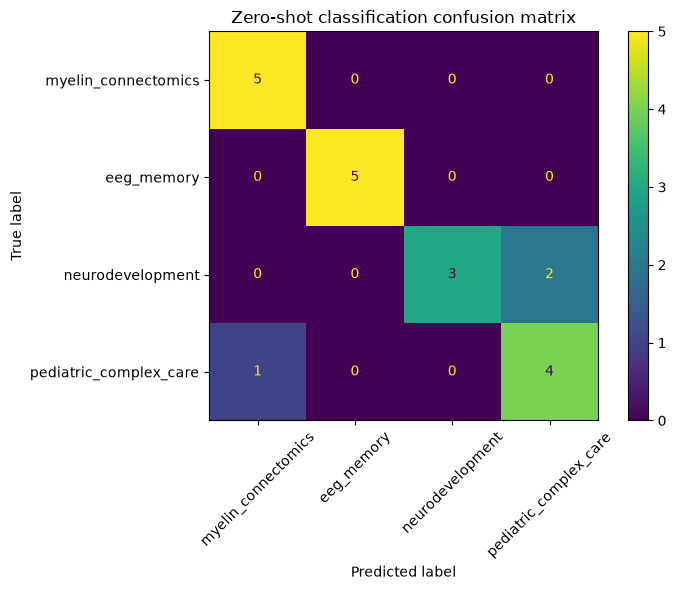

In [11]:
label_order = list(TOPICS.keys())

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    labels=label_order,
    xticks_rotation=45,
    ax=ax,
)
ax.set_title("Zero-shot classification confusion matrix")
plt.tight_layout()
plt.show()


In [12]:
classification_results["correct"] = (
    classification_results["source_topic"]
    == classification_results["predicted_topic"]
)

confidence_summary = (
    classification_results
    .groupby("correct")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
)

confidence_summary


,count,mean,median,min,max
correct,,,,,
False,3,0.639766,0.703258,0.493782,0.722259
True,17,0.785057,0.914554,0.304010,0.991106


In [13]:
with sqlite3.connect(SYNTHETIC_DB_PATH) as conn:
    classification_results.to_sql(
        "zero_shot_predictions",
        conn,
        if_exists="replace",
        index=False,
    )

    failure_query = """
    WITH prediction_audit AS (
        SELECT
            z.paper_id,
            p.title,
            z.source_topic,
            z.predicted_topic,
            z.confidence,
            CASE
                WHEN z.source_topic = z.predicted_topic THEN 1
                ELSE 0
            END AS correct
        FROM zero_shot_predictions AS z
        INNER JOIN papers AS p
            ON z.paper_id = p.paper_id
    )
    SELECT
        paper_id,
        title,
        source_topic,
        predicted_topic,
        ROUND(confidence, 3) AS confidence
    FROM prediction_audit
    WHERE correct = 0
    ORDER BY confidence DESC;
    """

    failures = pd.read_sql_query(failure_query, conn)

failures


,paper_id,title,source_topic,predicted_topic,confidence
0,P004,Home-based care and pediatric outcomes,pediatric_complex_care,myelin_connectomics,0.722
1,N005,Individual variation in developmental connecto...,neurodevelopment,pediatric_complex_care,0.703
2,N002,White-matter maturation across childhood,neurodevelopment,pediatric_complex_care,0.494


# Part II — Curated PubMed retrieval benchmark

The synthetic prototype is useful for debugging, but it is intentionally easy. Part II therefore replaces it with a small real-data benchmark.

### Corpus construction

A PubMed candidate pool was generated programmatically and then reviewed manually. The final benchmark contains **80 papers: 20 per topic** across:

- `white_matter_connectivity`
- `eeg_memory`
- `neurodevelopment`
- `pediatric_complex_care`

The first category was deliberately broadened from the prototype's narrower `myelin_connectomics` label after pilot PubMed searches showed that the original category was too restrictive for a balanced literature corpus.

Candidate-search provenance was kept separate from the final labels: papers were assigned a single `gold_topic` according to their primary scientific or clinical focus rather than simply inheriting the query that retrieved them.

Only PMIDs, DOIs, and the manually curated `gold_topic` labels are committed to the repository. Full abstracts are fetched locally with `scripts/fetch_curated_pubmed.py`.

### Retrieval experiment

Two methods are evaluated on the **same corpus, information needs, labels, and metrics**:

1. **SQLite FTS5/BM25** — a conventional lexical full-text-search baseline.
2. **MiniLM semantic retrieval** — dense Sentence Transformer embeddings ranked by cosine similarity.

This baseline comparison is important: a transformer method should not be assumed to add value simply because it is more complex.


## 5. Load the curated PubMed corpus

The hydrated corpus is generated locally from `data/pubmed_labels.csv`. The check below fails clearly if that acquisition step has not been run.


In [14]:
REAL_CORPUS_PATH = CACHE_DIR / "pubmed_curated.csv"

if not REAL_CORPUS_PATH.exists():
    raise FileNotFoundError(
        "Curated PubMed corpus not found. Run "
        "`python scripts/fetch_curated_pubmed.py` "
        "after setting the NCBI_EMAIL environment variable."
    )

real_corpus = pd.read_csv(
    REAL_CORPUS_PATH,
    dtype={"pmid": str},
)

print("Corpus shape:", real_corpus.shape)
display(
    real_corpus[
        ["paper_id", "title", "year", "gold_topic"]
    ].head(10)
)

print("\nGold-topic counts:")
display(
    real_corpus["gold_topic"]
    .value_counts()
    .rename("n")
    .to_frame()
)

print("\nMissing values:")
display(
    real_corpus[
        ["title", "abstract", "gold_topic"]
    ].isna().sum().to_frame("n_missing")
)

print("\nDocument-length summary:")
display(
    real_corpus["text"]
    .str.len()
    .describe()
    .to_frame("characters")
)


Corpus shape: (80, 9)


,paper_id,title,year,gold_topic
0,PMID_41926346,Neural-Context Reinstatement of Recurring Events.,2026,eeg_memory
1,PMID_40024366,Decoding auditory working memory content from ...,2025,eeg_memory
2,PMID_41395738,Decoding Auditory Working Memory Load From EEG...,2025,eeg_memory
3,PMID_40069364,Study-phase reinstatement predicts subsequent ...,2025,eeg_memory
4,PMID_39401083,Decoding load or selection in visuospatial wor...,2024,eeg_memory
5,PMID_38582783,EEG decoders track memory dynamics.,2024,eeg_memory
6,PMID_39033965,Decoding EEG for optimizing naturalistic memory.,2024,eeg_memory
7,PMID_38552414,Cortical and white matter substrates supportin...,2024,eeg_memory
8,PMID_39419472,Behavioral and electrophysiological evidence f...,2024,eeg_memory
9,PMID_36808118,EEG and pupillometric signatures of working me...,2023,eeg_memory



Gold-topic counts:


,n
gold_topic,
eeg_memory,20
neurodevelopment,20
white_matter_connectivity,20
pediatric_complex_care,20



Missing values:


,n_missing
title,0
abstract,0
gold_topic,0



Document-length summary:


,characters
count,80.000000
mean,1537.812500
std,414.989922
min,683.000000
25%,1241.000000
50%,1503.000000
75%,1853.500000
max,2915.000000


## 6. Store the curated corpus in SQLite

The real corpus is loaded into a separate SQLite database. A simple aggregation confirms corpus balance and provides a compact descriptive summary before retrieval begins.


In [15]:
if REAL_DB_PATH.exists():
    REAL_DB_PATH.unlink()

real_conn = sqlite3.connect(REAL_DB_PATH)

db_cols = [
    "paper_id",
    "pmid",
    "doi",
    "title",
    "abstract",
    "year",
    "journal",
    "gold_topic",
]

real_corpus[db_cols].to_sql(
    "papers",
    real_conn,
    if_exists="replace",
    index=False,
)

pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM papers;",
    real_conn,
)


,n
0,80


In [16]:
pd.read_sql_query(
    """
    SELECT
        gold_topic,
        COUNT(*) AS n_papers,
        MIN(year) AS earliest_year,
        MAX(year) AS latest_year,
        ROUND(AVG(year), 1) AS mean_year
    FROM papers
    GROUP BY gold_topic
    ORDER BY gold_topic;
    """,
    real_conn,
)


,gold_topic,n_papers,earliest_year,latest_year,mean_year
0,eeg_memory,20,2019,2026,2022.8
1,neurodevelopment,20,2018,2025,2022.1
2,pediatric_complex_care,20,2018,2025,2022.1
3,white_matter_connectivity,20,2018,2025,2022.5


## 7. Lexical baseline: SQLite FTS5 / BM25

SQLite FTS5 creates a full-text index over titles and abstracts. Its `bm25()` ranking provides a lightweight conventional information-retrieval baseline.

The search function returns the same metadata that will later be returned by semantic search, allowing an apples-to-apples comparison.


In [17]:
real_conn.execute("DROP TABLE IF EXISTS papers_fts;")

real_conn.execute(
    """
    CREATE VIRTUAL TABLE papers_fts
    USING fts5(
        paper_id UNINDEXED,
        title,
        abstract
    );
    """
)

real_conn.execute(
    """
    INSERT INTO papers_fts (
        paper_id,
        title,
        abstract
    )
    SELECT
        paper_id,
        title,
        abstract
    FROM papers;
    """
)

real_conn.commit()

pd.read_sql_query(
    "SELECT COUNT(*) AS n FROM papers_fts;",
    real_conn,
)


,n
0,80


In [18]:
def search_fts5(conn, query, top_k=5):
    sql = """
    SELECT
        p.paper_id,
        p.title,
        p.year,
        p.gold_topic,
        bm25(papers_fts) AS bm25_score
    FROM papers_fts
    JOIN papers AS p
        ON p.paper_id = papers_fts.paper_id
    WHERE papers_fts MATCH ?
    ORDER BY bm25_score
    LIMIT ?;
    """

    return pd.read_sql_query(
        sql,
        conn,
        params=(query, top_k),
    )

search_fts5(
    real_conn,
    '"white matter" AND tractography',
    top_k=5,
)


,paper_id,title,year,gold_topic,bm25_score
0,PMID_37707839,Advancements in Diffusion MRI Tractography for...,2024,white_matter_connectivity,-3.932894
1,PMID_28945294,Diffusion MRI fiber tractography of the brain.,2019,white_matter_connectivity,-3.686622
2,PMID_34293464,Structural white matter connectometry of readi...,2021,white_matter_connectivity,-3.556426
3,PMID_41324261,Cross-species standardised cortico-subcortical...,2025,white_matter_connectivity,-3.352410
4,PMID_40814567,TRANSFORMER-BASED T1-TRACTOGRAPHY.,2025,white_matter_connectivity,-3.351684


## 8. Define matched retrieval questions

The two retrieval systems receive differently formatted queries because FTS5 expects Boolean/phrase syntax while MiniLM accepts ordinary natural language. The underlying **information need** is kept the same.

For this benchmark, a retrieved paper is counted as relevant when its manually assigned `gold_topic` matches the expected topic.


In [19]:
RETRIEVAL_QUERIES = {
    "white_matter_connectivity": {
        "natural_query":
            "white matter structural connectivity and brain networks",
        "fts_query":
            '"white matter" AND '
            '(connectivity OR connectome OR tractography)',
    },

    "eeg_memory": {
        "natural_query":
            "EEG signals and electrophysiological mechanisms of memory",
        "fts_query":
            '(EEG OR electroencephalography) AND memory',
    },

    "neurodevelopment": {
        "natural_query":
            "development and maturation of brain connectivity",
        "fts_query":
            '(development OR maturation) '
            'AND (connectivity OR connectome OR network)',
    },

    "pediatric_complex_care": {
        "natural_query":
            "care and outcomes for children with medical complexity",
        "fts_query":
            '"medical complexity" '
            'OR "complex chronic conditions"',
    },
}


In [20]:
def precision_at_k(retrieved_topics, expected_topic, k=5):
    retrieved_topics = list(retrieved_topics[:k])
    relevant = sum(
        topic == expected_topic
        for topic in retrieved_topics
    )
    return relevant / k


def reciprocal_rank(retrieved_topics, expected_topic):
    for rank, topic in enumerate(
        retrieved_topics,
        start=1,
    ):
        if topic == expected_topic:
            return 1.0 / rank

    return 0.0


### FTS5/BM25 evaluation


In [21]:
fts_rows = []

for expected_topic, query_config in RETRIEVAL_QUERIES.items():
    results = search_fts5(
        real_conn,
        query_config["fts_query"],
        top_k=5,
    )

    topics = results["gold_topic"].tolist()

    fts_rows.append({
        "expected_topic": expected_topic,
        "query": query_config["natural_query"],
        "precision@5": precision_at_k(
            topics,
            expected_topic,
            k=5,
        ),
        "reciprocal_rank": reciprocal_rank(
            topics,
            expected_topic,
        ),
    })

fts_eval = pd.DataFrame(fts_rows)

display(fts_eval)
print(
    "Mean Precision@5:",
    round(fts_eval["precision@5"].mean(), 3),
)
print(
    "Mean Reciprocal Rank:",
    round(fts_eval["reciprocal_rank"].mean(), 3),
)


,expected_topic,query,precision@5,reciprocal_rank
0,white_matter_connectivity,white matter structural connectivity and brain...,1.0,1.0
1,eeg_memory,EEG signals and electrophysiological mechanism...,1.0,1.0
2,neurodevelopment,development and maturation of brain connectivity,1.0,1.0
3,pediatric_complex_care,care and outcomes for children with medical co...,1.0,1.0


Mean Precision@5: 1.0
Mean Reciprocal Rank: 1.0


## 9. Semantic retrieval on the same corpus

The same MiniLM model used in the prototype is now applied to all 80 real PubMed papers. Each natural-language query is embedded and ranked against the document embeddings using cosine similarity.


In [22]:
real_paper_embeddings = embedding_model.encode(
    real_corpus["text"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=False,
)

print("Embedding matrix shape:", real_paper_embeddings.shape)


Embedding matrix shape: (80, 384)


In [23]:
def semantic_search_real(
    query,
    corpus,
    corpus_embeddings,
    model,
    top_k=5,
):
    query_embedding = model.encode(
        [query],
        normalize_embeddings=True,
    )

    similarities = cosine_similarity(
        query_embedding,
        corpus_embeddings,
    )[0]

    ranking = similarities.argsort()[::-1][:top_k]

    results = corpus.iloc[ranking].copy()
    results["similarity"] = similarities[ranking]

    return results[
        [
            "paper_id",
            "title",
            "year",
            "gold_topic",
            "similarity",
        ]
    ]


### MiniLM evaluation


In [24]:
semantic_rows = []

for expected_topic, query_config in RETRIEVAL_QUERIES.items():
    results = semantic_search_real(
        query_config["natural_query"],
        real_corpus,
        real_paper_embeddings,
        embedding_model,
        top_k=5,
    )

    topics = results["gold_topic"].tolist()

    semantic_rows.append({
        "expected_topic": expected_topic,
        "query": query_config["natural_query"],
        "precision@5": precision_at_k(
            topics,
            expected_topic,
            k=5,
        ),
        "reciprocal_rank": reciprocal_rank(
            topics,
            expected_topic,
        ),
    })

semantic_eval = pd.DataFrame(semantic_rows)

display(semantic_eval)
print(
    "Mean Precision@5:",
    round(semantic_eval["precision@5"].mean(), 3),
)
print(
    "Mean Reciprocal Rank:",
    round(semantic_eval["reciprocal_rank"].mean(), 3),
)


,expected_topic,query,precision@5,reciprocal_rank
0,white_matter_connectivity,white matter structural connectivity and brain...,0.8,1.0
1,eeg_memory,EEG signals and electrophysiological mechanism...,1.0,1.0
2,neurodevelopment,development and maturation of brain connectivity,1.0,1.0
3,pediatric_complex_care,care and outcomes for children with medical co...,1.0,1.0


Mean Precision@5: 0.95
Mean Reciprocal Rank: 1.0


## 10. Compare lexical and semantic retrieval

The aggregate table summarizes performance across the four information needs, while the per-query table shows where the methods diverge.


In [25]:
comparison = pd.DataFrame(
    {
        "method": [
            "SQLite FTS5/BM25",
            "MiniLM semantic",
        ],
        "mean_precision@5": [
            fts_eval["precision@5"].mean(),
            semantic_eval["precision@5"].mean(),
        ],
        "mean_reciprocal_rank": [
            fts_eval["reciprocal_rank"].mean(),
            semantic_eval["reciprocal_rank"].mean(),
        ],
    }
)

comparison


,method,mean_precision@5,mean_reciprocal_rank
0,SQLite FTS5/BM25,1.00,1.0
1,MiniLM semantic,0.95,1.0


In [26]:
per_query_comparison = (
    fts_eval[
        ["expected_topic", "precision@5", "reciprocal_rank"]
    ]
    .rename(columns={
        "precision@5": "fts_precision@5",
        "reciprocal_rank": "fts_reciprocal_rank",
    })
    .merge(
        semantic_eval[
            ["expected_topic", "precision@5", "reciprocal_rank"]
        ].rename(columns={
            "precision@5": "semantic_precision@5",
            "reciprocal_rank": "semantic_reciprocal_rank",
        }),
        on="expected_topic",
        validate="one_to_one",
    )
)

per_query_comparison


,expected_topic,fts_precision@5,fts_reciprocal_rank,semantic_precision@5,semantic_reciprocal_rank
0,white_matter_connectivity,1.0,1.0,0.8,1.0
1,eeg_memory,1.0,1.0,1.0,1.0
2,neurodevelopment,1.0,1.0,1.0,1.0
3,pediatric_complex_care,1.0,1.0,1.0,1.0


### Interpretation

On the curated 80-paper benchmark used during development, **SQLite FTS5/BM25 achieved mean Precision@5 = 1.00**, while **MiniLM semantic retrieval achieved 0.95**. Both methods achieved **MRR = 1.00**.

This result is useful precisely because the transformer did **not** automatically outperform the simpler baseline. The corpus is small, balanced, and organized around fairly explicit biomedical terminology, which gives lexical matching a favorable setting. MiniLM remained highly competitive but introduced one off-topic result in the white-matter/connectivity query.

The comparison therefore supports a practical model-selection principle: **use the simplest method that satisfies the task, and evaluate added complexity against a credible baseline rather than assuming it is beneficial.**

These numbers should not be interpreted as a general benchmark of either retrieval method. Four broad queries and topic-level relevance labels provide a compact portfolio experiment, not a definitive information-retrieval study.


# Part III — Retrieval disagreement analysis

Aggregate metrics summarize performance, but they do not explain *why* two retrieval systems disagree. This section preserves the ranked results and inspects the single cross-topic result responsible for MiniLM's lower Precision@5.


## 11. Preserve ranked results from both methods

The top-five rankings from FTS5/BM25 and MiniLM are retained at the paper level so that the aggregate evaluation can be traced back to individual results.


In [27]:
retrieval_details = []

for expected_topic, query_config in RETRIEVAL_QUERIES.items():

    # Lexical search
    fts_results = search_fts5(
        real_conn,
        query_config["fts_query"],
        top_k=5,
    ).copy()

    fts_results["method"] = "FTS5/BM25"
    fts_results["rank"] = range(1, len(fts_results) + 1)
    fts_results["expected_topic"] = expected_topic

    retrieval_details.append(
        fts_results[
            [
                "expected_topic",
                "method",
                "rank",
                "paper_id",
                "title",
                "gold_topic",
            ]
        ]
    )

    # Semantic search
    semantic_results = semantic_search_real(
        query_config["natural_query"],
        real_corpus,
        real_paper_embeddings,
        embedding_model,
        top_k=5,
    ).copy()

    semantic_results["method"] = "MiniLM"
    semantic_results["rank"] = range(
        1,
        len(semantic_results) + 1,
    )
    semantic_results["expected_topic"] = expected_topic

    retrieval_details.append(
        semantic_results[
            [
                "expected_topic",
                "method",
                "rank",
                "paper_id",
                "title",
                "gold_topic",
            ]
        ]
    )

retrieval_details = pd.concat(
    retrieval_details,
    ignore_index=True,
)

retrieval_details.head()

,expected_topic,method,rank,paper_id,title,gold_topic
0,white_matter_connectivity,FTS5/BM25,1,PMID_34293464,Structural white matter connectometry of readi...,white_matter_connectivity
1,white_matter_connectivity,FTS5/BM25,2,PMID_38666220,The structural connectome in ADHD.,white_matter_connectivity
2,white_matter_connectivity,FTS5/BM25,3,PMID_38520376,Structural brain networks correlating with pos...,white_matter_connectivity
3,white_matter_connectivity,FTS5/BM25,4,PMID_37707839,Advancements in Diffusion MRI Tractography for...,white_matter_connectivity
4,white_matter_connectivity,FTS5/BM25,5,PMID_38438384,Genetic architecture of the structural connect...,white_matter_connectivity


## 12. Inspect the cross-topic retrieval

A result is flagged when its manually assigned `gold_topic` differs from the topic associated with the information need. The flagged paper is then joined back to the corpus to inspect its abstract, followed by a direct comparison of the two white-matter/connectivity rankings.


In [28]:
off_topic = retrieval_details[
    retrieval_details["gold_topic"]
    != retrieval_details["expected_topic"]
].copy()

off_topic

,expected_topic,method,rank,paper_id,title,gold_topic
9,white_matter_connectivity,MiniLM,5,PMID_31874926,Development of structure-function coupling in ...,neurodevelopment


In [29]:
off_topic_details = off_topic.merge(
    real_corpus[
        [
            "paper_id",
            "abstract",
        ]
    ],
    on="paper_id",
    how="left",
)

pd.set_option(
    "display.max_colwidth",
    1000,
)

display(
    off_topic_details[
        [
            "expected_topic",
            "rank",
            "title",
            "gold_topic",
            "abstract",
        ]
    ]
)

,expected_topic,rank,title,gold_topic,abstract
0,white_matter_connectivity,5,Development of structure-function coupling in human brain networks during youth.,neurodevelopment,"The protracted development of structural and functional brain connectivity within distributed association networks coincides with improvements in higher-order cognitive processes such as executive function. However, it remains unclear how white-matter architecture develops during youth to directly support coordinated neural activity. Here, we characterize the development of structure-function coupling using diffusion-weighted imaging and n-back functional MRI data in a sample of 727 individuals (ages 8 to 23 y). We found that spatial variability in structure-function coupling aligned with cortical hierarchies of functional specialization and evolutionary expansion. Furthermore, hierarchy-dependent age effects on structure-function coupling localized to transmodal cortex in both cross-sectional data and a subset of participants with longitudinal data (n = 294). Moreover, structure-function coupling in rostrolateral prefrontal cortex was associated with executive performance and part..."


In [30]:
target_topic = "white_matter_connectivity"

display(
    retrieval_details[
        retrieval_details["expected_topic"]
        == target_topic
    ].sort_values(
        ["method", "rank"]
    )
)

,expected_topic,method,rank,paper_id,title,gold_topic
0,white_matter_connectivity,FTS5/BM25,1,PMID_34293464,Structural white matter connectometry of reading and dyslexia.,white_matter_connectivity
1,white_matter_connectivity,FTS5/BM25,2,PMID_38666220,The structural connectome in ADHD.,white_matter_connectivity
2,white_matter_connectivity,FTS5/BM25,3,PMID_38520376,Structural brain networks correlating with poststroke cognition.,white_matter_connectivity
3,white_matter_connectivity,FTS5/BM25,4,PMID_37707839,Advancements in Diffusion MRI Tractography for Neurosurgery.,white_matter_connectivity
4,white_matter_connectivity,FTS5/BM25,5,PMID_38438384,Genetic architecture of the structural connectome.,white_matter_connectivity
5,white_matter_connectivity,MiniLM,1,PMID_29684403,White matter pathways and social cognition.,white_matter_connectivity
6,white_matter_connectivity,MiniLM,2,PMID_35945231,Human brain structural connectivity matrices-ready for modelling.,white_matter_connectivity
7,white_matter_connectivity,MiniLM,3,PMID_35149304,White matter microstructure in children and adolescents with ADHD.,white_matter_connectivity
8,white_matter_connectivity,MiniLM,4,PMID_38666220,The structural connectome in ADHD.,white_matter_connectivity
9,white_matter_connectivity,MiniLM,5,PMID_31874926,Development of structure-function coupling in human brain networks during youth.,neurodevelopment


### Interpretation

The sole off-topic MiniLM result occurred for the white-matter/connectivity query. MiniLM ranked *Development of structure-function coupling in human brain networks during youth* fifth, whereas the paper was manually assigned to `neurodevelopment` based on its primary scientific focus.

The disagreement is substantively interpretable rather than obviously spurious: the study directly examines white-matter architecture and structural connectivity in relation to functional brain networks, but does so in the context of developmental change. This highlights a limitation of the benchmark's single-topic relevance definition. A semantically related paper can be useful for a query while still being counted as incorrect because its primary gold label belongs to another category.

Under the present topic-level evaluation, FTS5/BM25 achieved perfect Precision@5 while MiniLM introduced one cross-topic result. The case illustrates both the strength of lexical retrieval for explicit biomedical terminology and the potentially broader notion of relevance captured by semantic embeddings.


# Part IV — Real-data zero-shot classification

Part I demonstrated that the zero-shot classification pipeline worked on controlled synthetic examples. The final experiment applies the same zero-shot DeBERTa model to the **80-paper curated PubMed corpus**.

The task is different from retrieval: instead of asking which papers best match a query, the classifier receives one paper at a time and chooses the most compatible topic from four natural-language candidate labels.

No task-specific training examples from this corpus are supplied to the classifier.


## 13. Define natural-language candidate labels

The human-readable labels supplied to DeBERTa are mapped back to the compact `gold_topic` codes used in the benchmark. Natural-language descriptions are preferable to machine-style labels such as `white_matter_connectivity` because the zero-shot model interprets the label text semantically.


In [31]:
REAL_CLASS_LABELS = {
    "white matter structural connectivity":
        "white_matter_connectivity",

    "EEG and memory":
        "eeg_memory",

    "brain development and neurodevelopment":
        "neurodevelopment",

    "pediatric complex care":
        "pediatric_complex_care",
}

real_candidate_labels = list(
    REAL_CLASS_LABELS.keys()
)

real_candidate_labels


['white matter structural connectivity',
 'EEG and memory',
 'brain development and neurodevelopment',
 'pediatric complex care']

## 14. Classify the curated PubMed corpus

Each paper's combined title and abstract is passed to the zero-shot classifier. The highest-scoring candidate label is retained together with the model's confidence score.


In [32]:
real_predictions = []

for row in real_corpus.itertuples(index=False):

    result = zero_shot(
        row.text,
        candidate_labels=real_candidate_labels,
        multi_label=False,
    )

    predicted_label = result["labels"][0]

    real_predictions.append({
        "paper_id": row.paper_id,
        "gold_topic": row.gold_topic,
        "predicted_label": predicted_label,
        "predicted_topic":
            REAL_CLASS_LABELS[predicted_label],
        "confidence": result["scores"][0],
    })

real_classification = pd.DataFrame(
    real_predictions
)

real_classification.head()


,paper_id,gold_topic,predicted_label,predicted_topic,confidence
0,PMID_41926346,eeg_memory,EEG and memory,eeg_memory,0.520874
1,PMID_40024366,eeg_memory,EEG and memory,eeg_memory,0.828976
2,PMID_41395738,eeg_memory,EEG and memory,eeg_memory,0.774117
3,PMID_40069364,eeg_memory,EEG and memory,eeg_memory,0.762149
4,PMID_39401083,eeg_memory,EEG and memory,eeg_memory,0.791161


## 15. Evaluate real-data classification

Accuracy gives the overall fraction of correct predictions, while macro-F1 gives each of the four classes equal weight. The confusion matrix then shows which topic boundaries are most difficult.


In [33]:
real_accuracy = accuracy_score(
    real_classification["gold_topic"],
    real_classification["predicted_topic"],
)

real_macro_f1 = f1_score(
    real_classification["gold_topic"],
    real_classification["predicted_topic"],
    average="macro",
)

print(
    f"Accuracy: {real_accuracy:.3f}"
)
print(
    f"Macro-F1: {real_macro_f1:.3f}"
)


Accuracy: 0.875
Macro-F1: 0.875


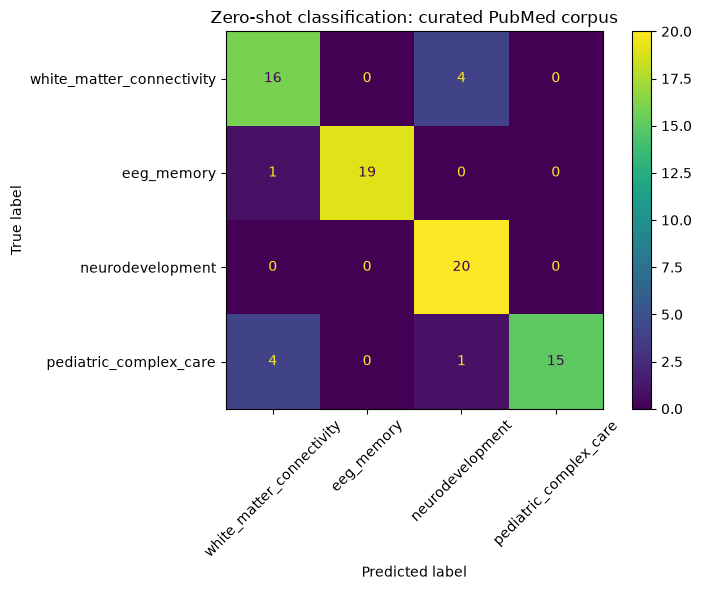

In [34]:
real_label_order = [
    "white_matter_connectivity",
    "eeg_memory",
    "neurodevelopment",
    "pediatric_complex_care",
]

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay.from_predictions(
    real_classification["gold_topic"],
    real_classification["predicted_topic"],
    labels=real_label_order,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title(
    "Zero-shot classification: curated PubMed corpus"
)

plt.tight_layout()
plt.show()


## 16. Inspect classification errors

Aggregate metrics can hide the nature of mistakes. The error table joins predictions back to paper titles and sorts misclassifications by model confidence so that the most confident failures appear first.


In [35]:
real_errors = (
    real_classification[
        real_classification["gold_topic"]
        != real_classification["predicted_topic"]
    ]
    .merge(
        real_corpus[
            [
                "paper_id",
                "title",
            ]
        ],
        on="paper_id",
        how="left",
    )
    .sort_values(
        "confidence",
        ascending=False,
    )
)

real_errors[
    [
        "title",
        "gold_topic",
        "predicted_topic",
        "confidence",
    ]
]


,title,gold_topic,predicted_topic,confidence
9,Miswiring of Frontostriatal Projections in Schizophrenia.,white_matter_connectivity,neurodevelopment,0.537098
3,Family-provider consensus outcomes for children with medical complexity.,pediatric_complex_care,white_matter_connectivity,0.475774
0,Cortical and white matter substrates supporting visuospatial working memory.,eeg_memory,white_matter_connectivity,0.402040
7,Scale matters: The nested human connectome.,white_matter_connectivity,neurodevelopment,0.389379
6,The Cortico-Limbo-Thalamo-Cortical Circuits: An Update to the Original Papez Circuit of the Human Limbic System.,white_matter_connectivity,neurodevelopment,0.379344
8,Mapping Structural Connectivity Using Diffusion MRI: Challenges and Opportunities.,white_matter_connectivity,neurodevelopment,0.312772
5,Families of Children With Medical Complexity: A View From the Front Lines.,pediatric_complex_care,white_matter_connectivity,0.309171
1,Characteristics and Outcomes of Children Discharged With Nasoenteral Feeding Tubes.,pediatric_complex_care,white_matter_connectivity,0.307341
2,Interfacility Transfers Among Patients With Complex Chronic Conditions.,pediatric_complex_care,white_matter_connectivity,0.290397
4,"Care Coordination for Children With Medical Complexity: Whose Care Is It, Anyway?",pediatric_complex_care,neurodevelopment,0.281321


## 17. Compare confidence for correct and incorrect predictions

Confidence is not treated as a calibrated probability. It is used descriptively to ask whether the classifier tends to be less certain on the cases it gets wrong.


In [36]:
real_classification["correct"] = (
    real_classification["gold_topic"]
    == real_classification["predicted_topic"]
)

real_confidence_summary = (
    real_classification
    .groupby("correct")["confidence"]
    .agg(["count", "mean", "median", "min", "max"])
)

real_confidence_summary


,count,mean,median,min,max
correct,,,,,
False,10,0.368464,0.346058,0.281321,0.537098
True,70,0.613803,0.632734,0.292256,0.961920


### Interpretation

The zero-shot DeBERTa classifier achieved **87.5% accuracy** and **macro-F1 = 0.875** on the curated 80-paper PubMed corpus despite receiving no task-specific training examples.

Performance varied by topic. The classifier correctly identified **20/20 neurodevelopment**, **19/20 EEG-memory**, **16/20 white-matter/connectivity**, and **15/20 pediatric-complex-care** papers. Many errors occurred at meaningful conceptual boundaries rather than representing obviously unrelated predictions. For example, a working-memory paper explicitly centered on cortical and white-matter substrates was predicted as white-matter connectivity, while several structural-connectome papers with developmental framing were predicted as neurodevelopment.

Confidence analysis supports this interpretation. Correct classifications had a mean confidence of **0.614** (median **0.633**), compared with **0.368** (median **0.346**) for errors. The confidence scores are not calibrated probabilities, but the separation indicates that mistakes tended to occur when the model itself was relatively uncertain.


## 18. Close the real-data database connection

The SQLite connection is closed only after all retrieval and classification analyses that depend on it have finished.


In [37]:
real_conn.close()


# Conclusions and limitations

## What the project shows

The completed workflow progresses from a deterministic prototype to a curated real-data benchmark:

- **SQLite** provides relational storage, exploratory SQL, and a strong FTS5/BM25 lexical-search baseline.
- **MiniLM** embeddings enable natural-language semantic retrieval without requiring exact keyword matching.
- **DeBERTa** provides useful four-way biomedical topic classification without task-specific fine-tuning.
- Retrieval and classification are evaluated quantitatively rather than judged only from plausible-looking outputs.
- Baseline comparisons and failure cases are inspected directly instead of being hidden.

On the curated retrieval benchmark, **FTS5/BM25 achieved mean Precision@5 = 1.00** and **MiniLM achieved 0.95**; both achieved **MRR = 1.00**. The simpler lexical method therefore slightly outperformed semantic retrieval under the current topic-level evaluation. The sole MiniLM cross-topic result was nevertheless scientifically related to the query, illustrating the difference between strict single-label scoring and broader semantic relevance.

On the curated classification benchmark, the zero-shot classifier achieved **87.5% accuracy** and **macro-F1 = 0.875**. Errors concentrated at interpretable boundaries between overlapping biomedical topics and were associated with lower classifier confidence.

## Important limitations

1. The PubMed benchmark contains only **80 papers** and four broad, deliberately balanced topic classes.
2. `gold_topic` is a single primary-topic annotation, not a query-specific or multi-label expert relevance judgment.
3. Only four retrieval information needs are evaluated, so aggregate retrieval metrics are sensitive to individual cases.
4. The candidate corpus was produced through targeted PubMed searches and is not representative of PubMed as a whole.
5. Only one dense retrieval model and one zero-shot classification model are tested.
6. Zero-shot confidence scores are useful for relative inspection but should not be interpreted as calibrated probabilities.
7. A production literature-search system would require a much larger corpus, scalable indexing, richer relevance judgments, monitoring, latency/cost evaluation, and stronger deployment-oriented testing.

## High-value next steps

- add multiple paraphrased or terminology-mismatched queries per topic;
- collect query-specific or multi-label relevance judgments;
- evaluate hybrid lexical + semantic retrieval;
- compare alternative embedding/classification models;
- validate the repository from a completely fresh environment and add automated tests.

## Portfolio summary

> I built an end-to-end biomedical literature retrieval and classification workflow using SQL and Hugging Face pretrained transformers. I first validated the pipeline on deterministic synthetic data, then generated and manually curated an 80-paper PubMed benchmark. I compared SQLite FTS5/BM25 lexical retrieval with MiniLM sentence embeddings using the same information needs, labels, Precision@5, and MRR metrics, and inspected the methods' disagreements at the document level. I also evaluated DeBERTa zero-shot classification on the real corpus, achieving 87.5% accuracy and macro-F1 of 0.875, with confusion-matrix, confidence, and failure-case analysis.
